# NBA Exploratory Data Analysis

Rhys Pulling

This project is aimed at analyzing various data from the NBA, with the end goal being trying to create a model that can help predict the MVP of a season based on various factors. This notebook is simply accessing the data from the nba_api Python library and doing exploratory data analysis on it. Currently, we are only looking at seasons from 2000 and on.

In [1]:
# !pip install pandas numpy matplotlib seaborn scikit-learn plotly.express nbformat nba_api

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time
import plotly.express as px
from nba_api.stats.endpoints import leaguedashplayerstats
from nba_api.stats.endpoints import leaguedashteamstats

## Importing Data

We first need to read in a fair amount of seasons using the API and storing it into a pandas data frame. We can ask for seaosns for the past 25 years and see if this is enough to find a pattern for todays league. We want player stats, team stats, as well as whether or not that individual was the MVP that season. We can make some quick function to do this and then store them all in one large data frame.

In [3]:
def get_player_stats(season):
    """
    Fetch player stats for a given player ID and season.
    """
    stats = leaguedashplayerstats.LeagueDashPlayerStats(season=season, season_type_all_star='Regular Season')
    df = stats.get_data_frames()[0]
    df["SEASON"] = season
    return df

def get_team_stats(season):
    """
    Fetch team stats for a given season.
    """
    teams = leaguedashteamstats.LeagueDashTeamStats(season=season, season_type_all_star='Regular Season')
    df = teams.get_data_frames()[0]
    df['SEASON'] = season
    return df[['TEAM_ID', 'TEAM_NAME', 'W', 'L', 'W_PCT', 'SEASON']]


In [4]:
all_seasons = []
for year in range(2000, 2024):
    season = f"{year}-{str(year + 1)[-2:]}"
    try:
        df_season = get_player_stats(season)
        df_team = get_team_stats(season)  
        df_season = df_season.merge(df_team, on=['SEASON', 'TEAM_ID'], how='left', suffixes=('', '_team'))
        all_seasons.append(df_season)
        print(f"Fetched data for {season}")
    except Exception as e:
        print(f"Error fetching data for {season}: {e}")
    time.sleep(1)  # To avoid hitting API rate limits

df_nba = pd.concat(all_seasons, ignore_index=True)

Fetched data for 2000-01
Fetched data for 2001-02
Fetched data for 2002-03
Fetched data for 2003-04
Fetched data for 2004-05
Fetched data for 2005-06
Fetched data for 2006-07
Fetched data for 2007-08
Fetched data for 2008-09
Fetched data for 2009-10
Fetched data for 2010-11
Fetched data for 2011-12
Fetched data for 2012-13
Fetched data for 2013-14
Fetched data for 2014-15
Fetched data for 2015-16
Fetched data for 2016-17
Fetched data for 2017-18
Fetched data for 2018-19
Fetched data for 2019-20
Fetched data for 2020-21
Fetched data for 2021-22
Fetched data for 2022-23
Fetched data for 2023-24


In [5]:
mvp_dict = {
    '2000-01': 'Allen Iverson',
    '2001-02': 'Tim Duncan',
    '2002-03': 'Tim Duncan',
    '2003-04': 'Kevin Garnett',
    '2004-05': 'Steve Nash',
    '2005-06': 'Steve Nash',
    '2006-07': 'Dirk Nowitzki',
    '2007-08': 'Kobe Bryant',
    '2008-09': 'LeBron James',
    '2009-10': 'LeBron James',
    '2010-11': 'Derrick Rose',
    '2011-12': 'LeBron James',
    '2012-13': 'LeBron James',
    '2013-14': 'Kevin Durant',
    '2014-15': 'Stephen Curry',
    '2015-16': 'Stephen Curry',
    '2016-17': 'Russell Westbrook',
    '2017-18': 'James Harden',
    '2018-19': 'Giannis Antetokounmpo',
    '2019-20': 'Giannis Antetokounmpo',
    '2020-21': 'Nikola Jokic',
    '2021-22': 'Nikola Jokic',
    '2022-23': 'Joel Embiid',
    '2023-24': 'Nikola Jokic'
}

def normalize_name(name):
    return name.lower().replace('.', '').replace(' ', '')

normalized_mvp_dict = {season: normalize_name(name) for season, name in mvp_dict.items()}

def assign_mvp_flag(row):
    season = row['SEASON']
    player = normalize_name(row['PLAYER_NAME'])
    return 1 if normalized_mvp_dict.get(season, '') == player else 0

df_nba['IS_MVP'] = df_nba.apply(assign_mvp_flag, axis=1)

In [6]:
df_nba.head()

,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,...,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,SEASON,TEAM_NAME,W_team,L_team,W_PCT_team,IS_MVP
0,920,A.C. Green,A.C.,1610612748,MIA,37.0,82,50,32,0.610,...,218,126,26,223,2000-01,Miami Heat,50,32,0.610,0
1,2062,A.J. Guyton,A.J.,1610612741,CHI,23.0,33,6,27,0.182,...,317,224,26,314,2000-01,Chicago Bulls,15,67,0.183,0
2,243,Aaron McKie,Aaron,1610612755,PHI,28.0,76,51,25,0.671,...,84,77,4,81,2000-01,Philadelphia 76ers,56,26,0.683,0
3,1425,Aaron Williams,Aaron,1610612751,NJN,29.0,82,26,56,0.317,...,77,53,26,79,2000-01,New Jersey Nets,26,56,0.317,0
4,228,Adam Keefe,Adam,1610612744,GSW,31.0,67,14,53,0.209,...,274,224,26,280,2000-01,Golden State Warriors,17,65,0.207,0


## Data Cleaning

The first thing we want to do is clean the data. This will include removing/filling any missing information and removing any unneeded variables. This will be helpful as there are certain features that won't tell us anything about the player that would be important for predicting MVP (such as "nickname"). 

In [7]:
df_nba.isna().sum().sum()

np.int64(0)

Right off the bat, we don't have any missing values which is really useful and most likely means we have good data. Now we can look at the columns and see which we can immediately remove. The most obvious ones are:
- Player / Team IDs: Don't actually mean anything
- NICKNAME: Fun to know, but not useful information
- TEAM_ABBREVIATION: We have the full team name
- TEAM_CITY: Location shouldn't impact the MVP
- WNBA_FANTASY_PTS(RANK): It is not relevant for NBA information, especially if we keep NBA_FANTASY_POINTS

In [8]:
df_nba.columns

Index(['PLAYER_ID', 'PLAYER_NAME', 'NICKNAME', 'TEAM_ID', 'TEAM_ABBREVIATION',
       'AGE', 'GP', 'W', 'L', 'W_PCT', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M',
       'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST',
       'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS',
       'NBA_FANTASY_PTS', 'DD2', 'TD3', 'WNBA_FANTASY_PTS', 'GP_RANK',
       'W_RANK', 'L_RANK', 'W_PCT_RANK', 'MIN_RANK', 'FGM_RANK', 'FGA_RANK',
       'FG_PCT_RANK', 'FG3M_RANK', 'FG3A_RANK', 'FG3_PCT_RANK', 'FTM_RANK',
       'FTA_RANK', 'FT_PCT_RANK', 'OREB_RANK', 'DREB_RANK', 'REB_RANK',
       'AST_RANK', 'TOV_RANK', 'STL_RANK', 'BLK_RANK', 'BLKA_RANK', 'PF_RANK',
       'PFD_RANK', 'PTS_RANK', 'PLUS_MINUS_RANK', 'NBA_FANTASY_PTS_RANK',
       'DD2_RANK', 'TD3_RANK', 'WNBA_FANTASY_PTS_RANK', 'SEASON', 'TEAM_NAME',
       'W_team', 'L_team', 'W_PCT_team', 'IS_MVP'],
      dtype='object')

In [9]:
drop_columns = ['NICKNAME', 'TEAM_ABBREVIATION', 'TEAM_CITY', 'TEAM_ID', 'PLAYER_ID', 'WNBA_FANTASY_PTS', 'WNBA_FANTASY_PTS_RANK']
df_nba.drop(columns=drop_columns, inplace=True, errors='ignore')
df_nba.rename(columns={'PLAYER_NAME': 'PLAYER', 'TEAM_NAME': 'TEAM'}, inplace=True)

In [10]:
print(f"Data shape after cleaning: {df_nba.shape}")
df_nba.drop_duplicates(inplace=True)
print(f"Data shape after removing duplicates: {df_nba.shape}")

Data shape after cleaning: (11659, 66)
Data shape after removing duplicates: (11659, 66)


More preprocessing will need to be done before we use the data in any models (standardizing, one-hot-encoding, etc.), but for now this should be enough for the EDA.

## Descriptive Statistics

The next thing we want to do is take a look just the descriptive statistics regarding the data. This will include information about the data frame itself, as well as looking at the distributions for each of the variables. 

In [11]:
print(f"Data shape after cleaning: {df_nba.shape}")
print(f"Number of unique players: {df_nba['PLAYER'].nunique()}")
print(f"Number of unique teams: {df_nba['TEAM'].nunique()}")

Data shape after cleaning: (11659, 66)
Number of unique players: 2367
Number of unique teams: 37


In [12]:
df_nba.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11659 entries, 0 to 11658
Data columns (total 66 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PLAYER                11659 non-null  object 
 1   AGE                   11659 non-null  float64
 2   GP                    11659 non-null  int64  
 3   W                     11659 non-null  int64  
 4   L                     11659 non-null  int64  
 5   W_PCT                 11659 non-null  float64
 6   MIN                   11659 non-null  float64
 7   FGM                   11659 non-null  int64  
 8   FGA                   11659 non-null  int64  
 9   FG_PCT                11659 non-null  float64
 10  FG3M                  11659 non-null  int64  
 11  FG3A                  11659 non-null  int64  
 12  FG3_PCT               11659 non-null  float64
 13  FTM                   11659 non-null  int64  
 14  FTA                   11659 non-null  int64  
 15  FT_PCT             

In [13]:
df_nba.describe()

,AGE,GP,W,L,W_PCT,MIN,FGM,FGA,FG_PCT,FG3M,...,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,W_team,L_team,W_PCT_team,IS_MVP
count,11659.000000,11659.000000,11659.000000,11659.000000,11659.000000,11659.000000,11659.000000,11659.000000,11659.000000,11659.000000,...,11659.000000,11659.000000,11659.000000,11659.000000,11659.000000,11659.000000,11659.000000,11659.000000,11659.000000,11659.000000
mean,26.852989,51.160048,25.582468,25.577580,0.487058,1194.128905,188.056437,412.456471,0.437891,40.171456,...,218.485805,245.296681,244.953684,245.604254,173.301998,24.721245,39.961918,40.401149,0.497039,0.001801
std,4.315369,25.076102,15.826413,14.506139,0.183266,882.889244,172.116493,368.295680,0.102347,52.008223,...,147.004535,143.920087,144.211188,144.227369,76.839509,8.732486,12.258786,12.177558,0.149545,0.042404
min,18.000000,1.000000,0.000000,0.000000,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000,9.000000,0.106000,0.000000
25%,24.000000,31.000000,13.000000,14.000000,0.362000,371.810000,43.000000,102.000000,0.400000,1.000000,...,86.000000,122.000000,122.000000,122.000000,113.000000,18.000000,31.000000,31.000000,0.390000,0.000000
50%,26.000000,58.000000,25.000000,26.000000,0.500000,1108.078333,144.000000,322.000000,0.439000,15.000000,...,190.000000,243.000000,242.000000,243.000000,203.000000,25.000000,41.000000,40.000000,0.512000,0.000000
75%,30.000000,73.000000,38.000000,36.000000,0.613000,1905.491667,287.000000,631.000000,0.484000,65.000000,...,343.000000,364.000000,364.000000,365.000000,233.000000,29.000000,49.000000,49.000000,0.610000,0.000000
max,44.000000,85.000000,73.000000,71.000000,1.000000,3484.070000,978.000000,2173.000000,1.000000,402.000000,...,564.000000,582.000000,605.000000,605.000000,268.000000,40.000000,73.000000,72.000000,0.890000,1.000000


In [14]:
df_nba.describe(include='object')

,PLAYER,SEASON,TEAM
count,11659,11659,11659
unique,2367,24,37
top,LeBron James,2021-22,Cleveland Cavaliers
freq,21,605,406


### Boxplots

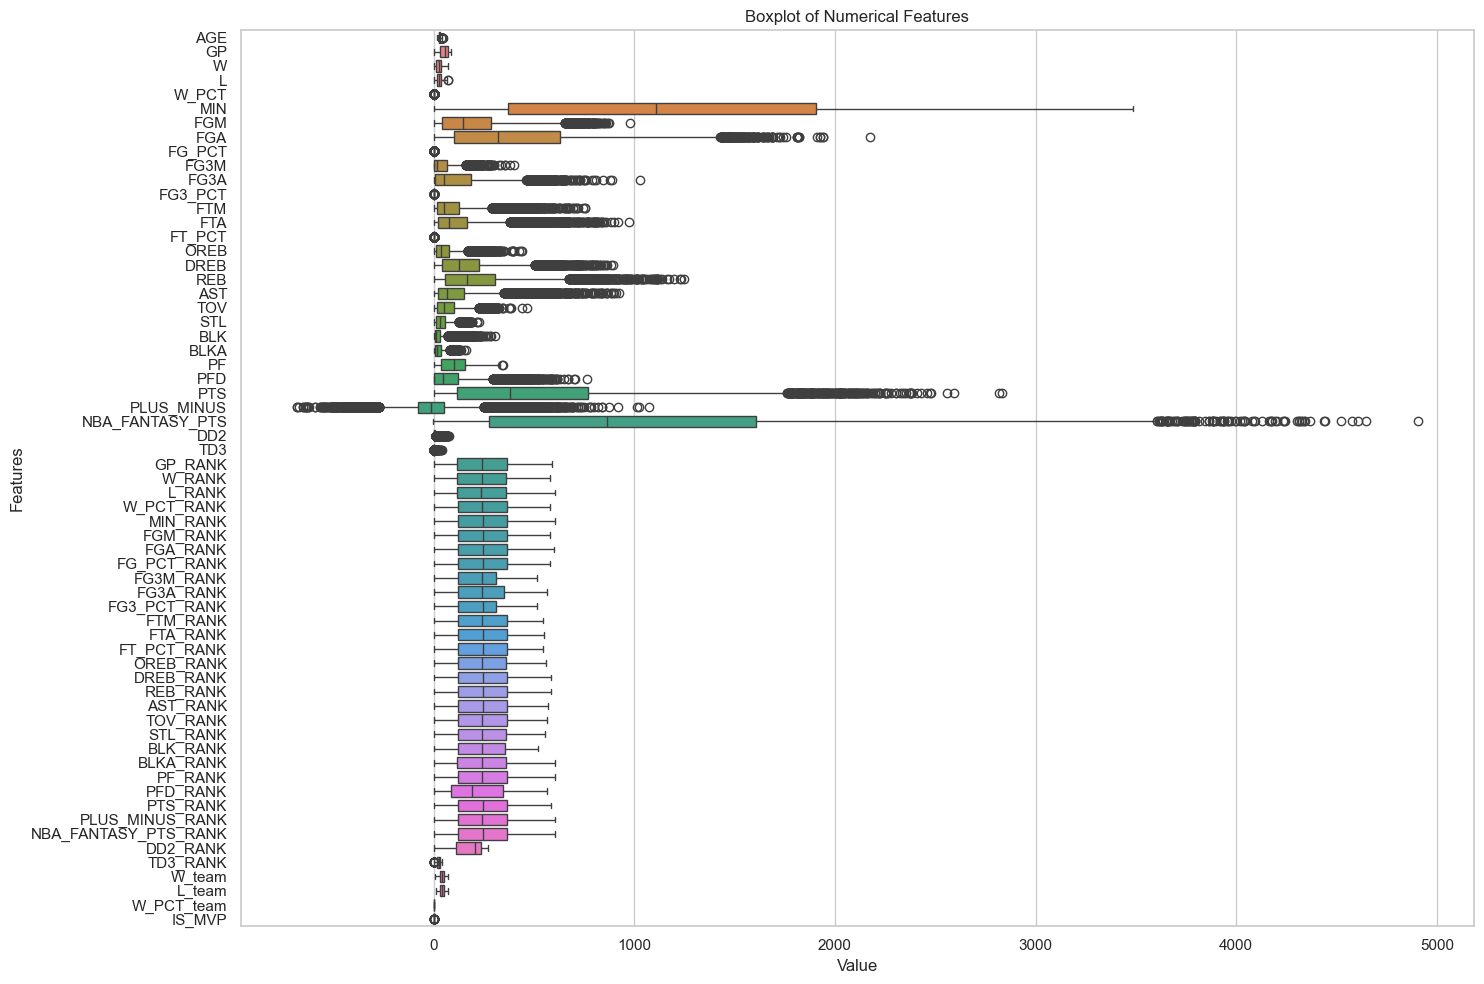

In [15]:
numerical_columns = df_nba.select_dtypes(include=[np.number]).columns.tolist()

sns.set(style = "whitegrid")
plt.figure(figsize=(15, 10))
sns.boxplot(data=df_nba[numerical_columns], orient='h')
plt.title('Boxplot of Numerical Features')
plt.xlabel('Value')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

This really just lets us look at the distribution for each of the variables as well as shows us there are certain outliers in the data. We don't want to remove outliers as it is actual data and it would be reasonable for players who are performing REALLY good seasons will have outliers in their season that show how good they were playing. Something that may be helpful is looking at Boxplots for those who won MVP and those who didn't. To make it easier, we can just look at a few features.

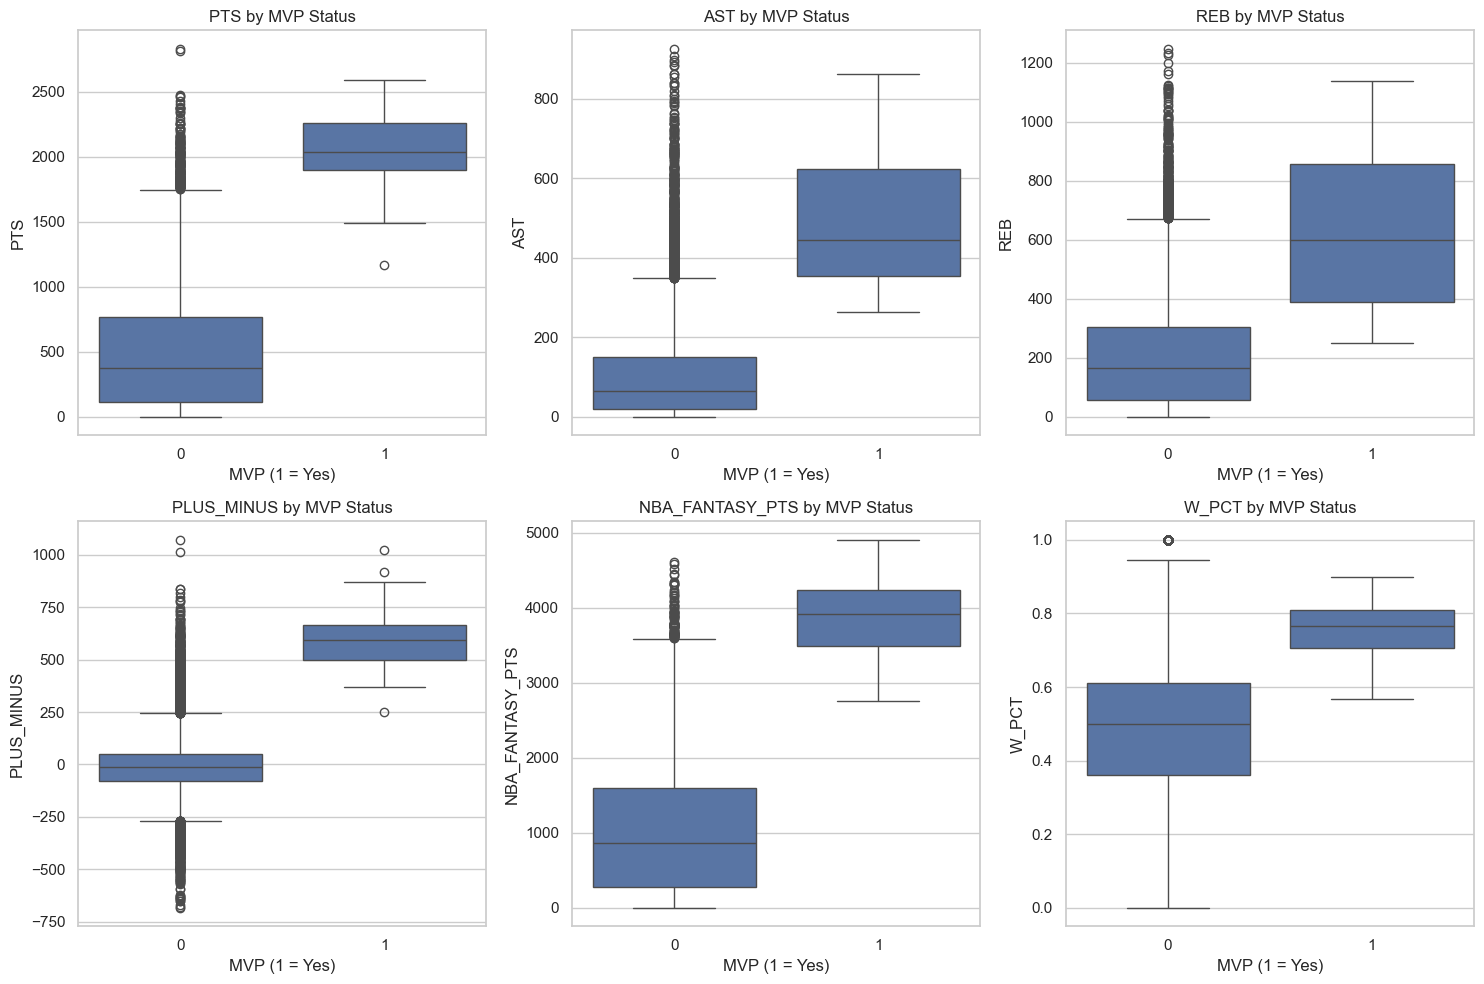

In [16]:
features = ['PTS', 'AST', 'REB', 'PLUS_MINUS', 'NBA_FANTASY_PTS', 'W_PCT']

sns.set(style="whitegrid")
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df_nba, x='IS_MVP', y=feature)
    plt.title(f'{feature} by MVP Status')
    plt.xlabel('MVP (1 = Yes)')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

We see that, on average, MVP players have more points, assists, rebounds, plus_minus, fantasy points, and win percentage. We would expect this trend to continue for a lot of the features in the data. 

### Histograms

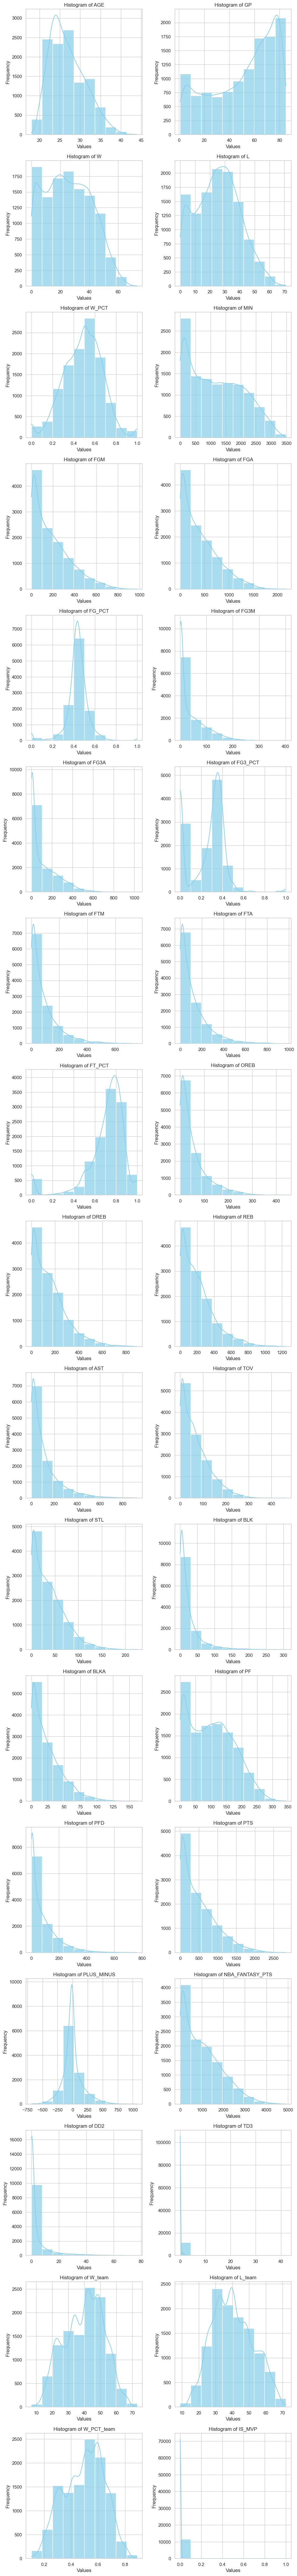

In [17]:
ncols = len(df_nba.columns)  # Number of columns in the DataFrame
nrows = (ncols + 1) // 2  # Adjust the number of rows based on columns (2 columns per row)

fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(10, nrows * 5))

# Flatten the axes array if there are more than one row
axes = axes.flatten()

# Plot histograms for each column in the DataFrame
dist_columns = df_nba.select_dtypes(include=[np.number]).columns.tolist()
dist_columns = [col for col in dist_columns if "RANK" not in col and "RATING" not in col]  # Exclude rank and rating columns
for i, column in enumerate(dist_columns):
    sns.histplot(df_nba[column], bins=10, kde=True, ax=axes[i], color='skyblue', alpha=0.7)
    axes[i].set_title(f'Histogram of {column}')
    axes[i].set_xlabel('Values')
    axes[i].set_ylabel('Frequency')

# Remove any unused axes if the grid is not fully filled
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

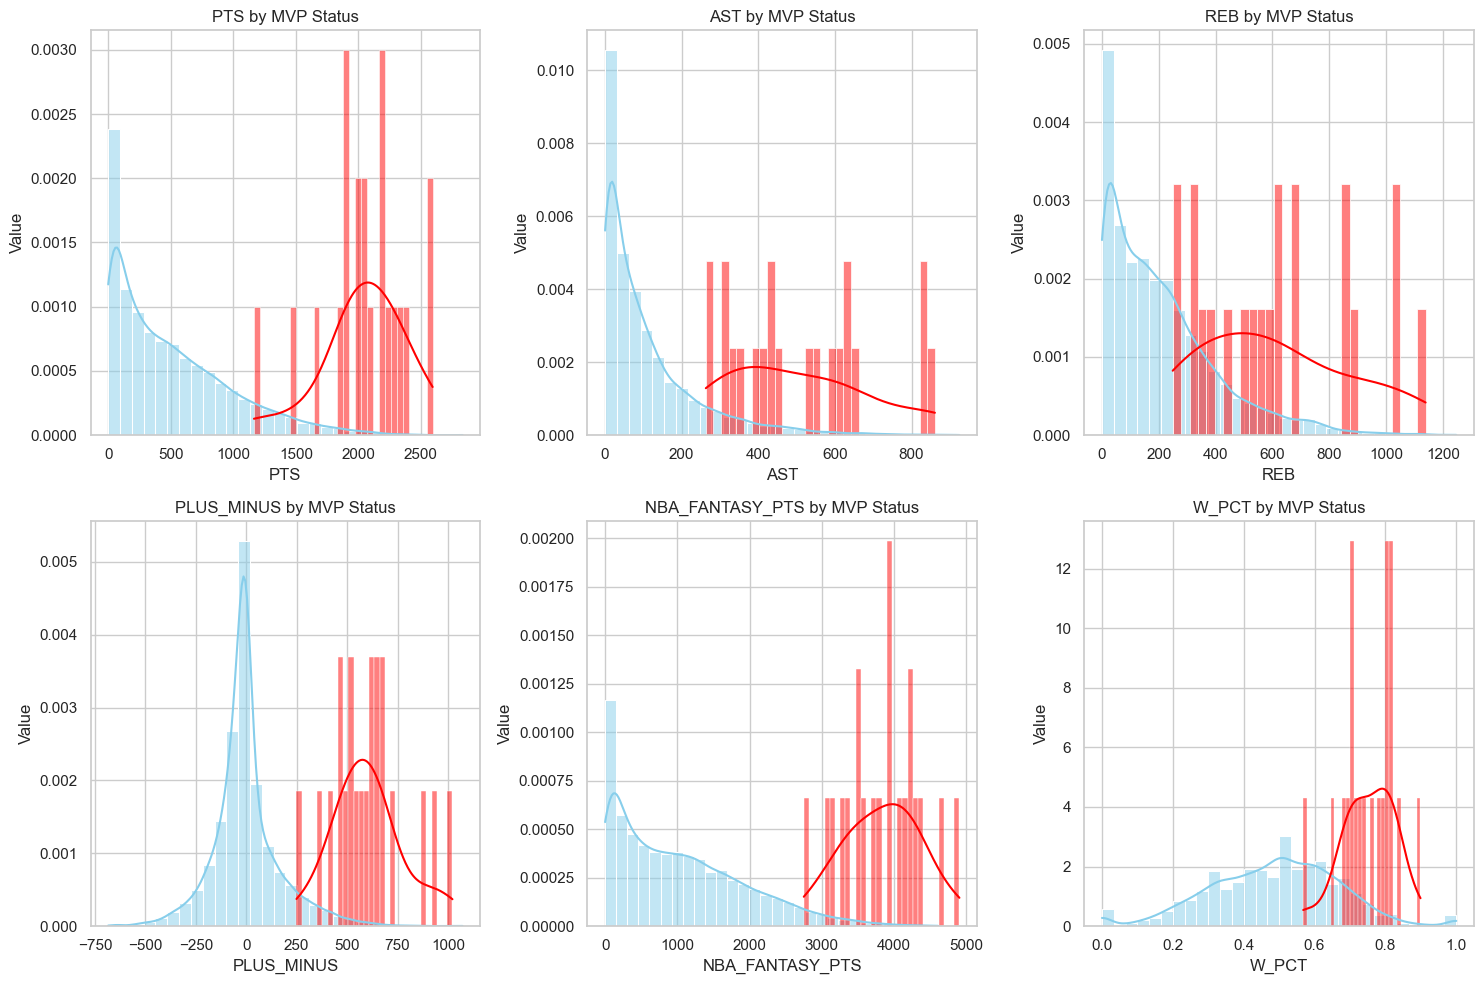

In [18]:
features = ['PTS', 'AST', 'REB', 'PLUS_MINUS', 'NBA_FANTASY_PTS', 'W_PCT']

sns.set(style="whitegrid")
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    # Plot MVPs and non-MVPs on the same histogram
    sns.histplot(df_nba[df_nba['IS_MVP'] == 0][feature], 
                 color='skyblue', label='Non-MVP', stat='density', kde=True, bins=30)
    sns.histplot(df_nba[df_nba['IS_MVP'] == 1][feature], 
                 color='red', label='MVP', stat='density', kde=True, bins=30)
    plt.title(f'{feature} by MVP Status')
    plt.xlabel(feature)
    plt.ylabel("Value")

plt.tight_layout()
plt.show()

## Trend Analysis

Here we can look at the overall trend for each variable, and overlay it with the MVP seasons. Currently, each plot shares the same scale so some plots don't really tell us much. 

In [22]:
# Group by season for all players
avg_all = df_nba.groupby('SEASON')[['PTS', 'AST', 'REB', 'NBA_FANTASY_PTS', 'W_PCT']].mean()
avg_all['Type'] = 'All Players'
avg_all = avg_all.reset_index()

# Group by season for MVPs only
avg_mvp = df_nba[df_nba['IS_MVP'] == 1].groupby('SEASON')[['PTS', 'AST', 'REB', 'NBA_FANTASY_PTS', 'W_PCT']].mean()
avg_mvp['Type'] = 'MVPs Only'
avg_mvp = avg_mvp.reset_index()


avg_combined = pd.concat([avg_all, avg_mvp])
df_melted = avg_combined.melt(id_vars=['SEASON', 'Type'], 
                              var_name='Feature', value_name='Average')

fig = px.line(df_melted, x='SEASON', y='Average', color='Type', 
              line_dash='Type', facet_col='Feature', 
              facet_col_wrap=2, markers=True,
              title='Trends of Player Stats: All Players vs MVPs',
              facet_row_spacing=0.1, facet_col_spacing=0.1)
fig.update_layout(height=700, legend_title='Group',
                  xaxis_title='Season', yaxis_title='Average Value')

fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))  # Clean up facet titles

fig.show()

## Relationships

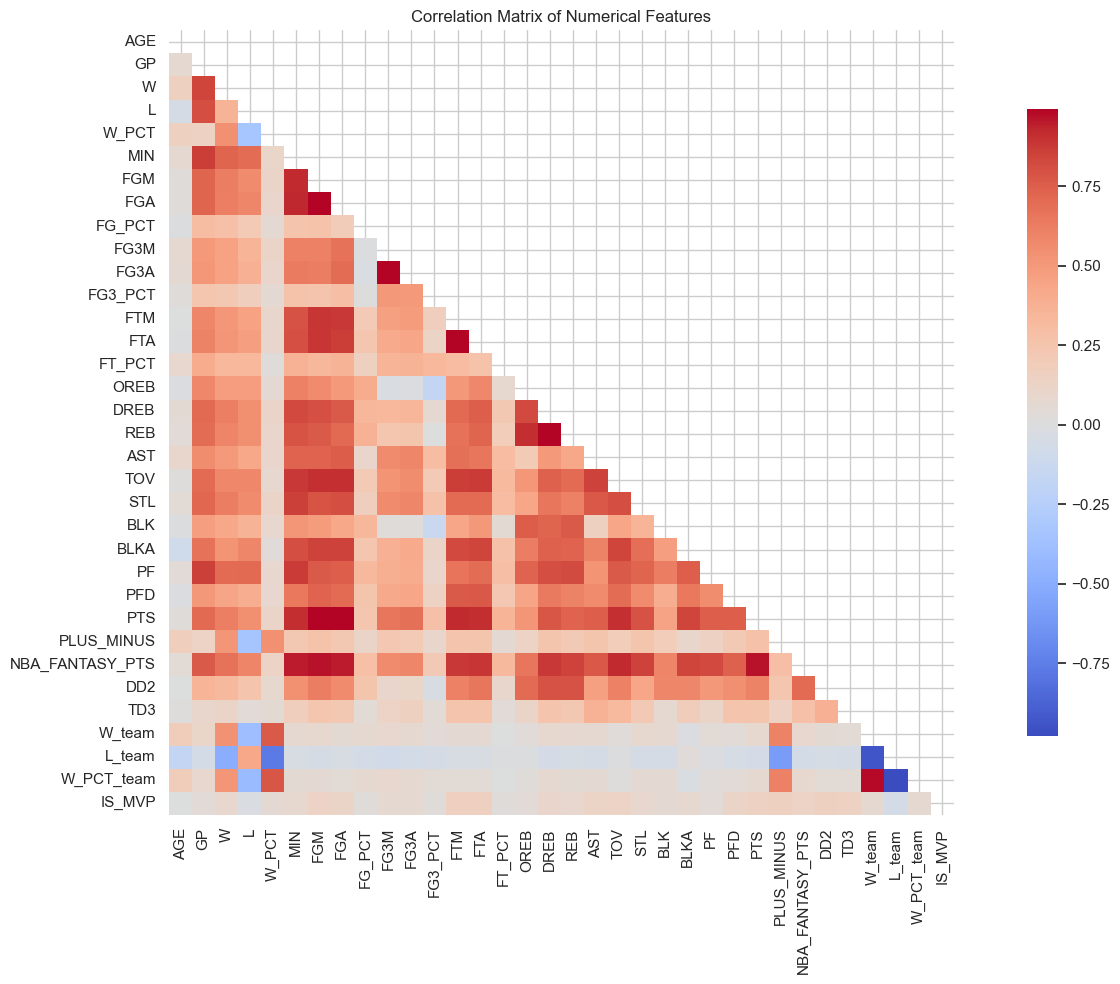

In [27]:
numeric_df = df_nba.select_dtypes(include=[np.number])
numeric_df = numeric_df.drop(columns=[col for col in numeric_df.columns if "RANK" in col], errors='ignore')  # Drop non-numeric columns
corr_matrix = numeric_df.corr()
plt.figure(figsize=(15, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

This actually tells us that nothing has a linear relationship/correlation with the IS_MVP variable. This most likely means we shouldn't use a linear model, but this result may be caused by the one-hot-encoded nature of the IS_MVP variable. 

In [32]:
# predictor_cols = [col for col in dist_columns if col != "IS_MVP"]

# # Create subplots: 2 rows x 7 columns
# fig, axes = plt.subplots(5, 7, figsize=(20, 6))
# axes = axes.flatten()

# # Loop through predictors and plot
# for i, predictor in enumerate(predictor_cols):
#     jitter = np.random.normal(0, 0.05, size=len(df_nba))
#     sns.scatterplot(data=df_nba, x='PTS', y=df_nba['IS_MVP'] + jitter, alpha=0.5)
#     axes[i].set_title(predictor)

# # Hide the extra subplot (14th subplot)
# if len(predictor_cols) < len(axes):
#     for j in range(len(predictor_cols), len(axes)):
#         axes[j].axis('off')

# plt.tight_layout()
# plt.show()